In [1]:
"""
This script performs virtual perturbation on the Ma2024Aging dataset,
"""
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
from scipy.stats import wasserstein_distance
import sys
# sys.path.append("/inspire/ssd/project/sais-lifescience/Brainbeacon/brainbeacon")
sys.path.append("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/brainbeacon")
from model_cdniche.pipeline.cell_embedding import run_bbcellformer_pipeline
from model_cdniche.pipeline.perturbation import apply_gene_perturbation, inject_cells_into_niche, plot_cosine_to_centroids_with_perturb
from model_cdniche.pipeline.perturbation import analyze_embedding_similarity_change, analyze_gene_reconstruction_change
from model_cdniche.utils import set_seed
from config.config_cdniche import GENE_DICT_PATH
from config.config_train_cdniche import config_train
from model_cdniche.utils import compute_density_token, compute_deviation_bin_rapid_v2
from model_cdniche.utils import convert_spatial_to_um, platform_radius_map
import logging
logging.basicConfig(
    level=logging.INFO,  # 或 level=logging.DEBUG
    format='%(asctime)s %(levelname)s %(message)s'
)

import warnings
import matplotlib.pyplot as plt
plt.rcParams["pdf.fonttype"] = 42
warnings.filterwarnings("ignore")
set_seed(42)

In [4]:
# Set GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

# Define base paths and dataset info
BASE_DIR = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/"
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig4_subfig_OE"
os.makedirs(out_fig_dir, exist_ok=True)

Using device: cuda
Using GPU: NVIDIA H800


In [5]:

# ========== 1. Dataset and Basic Setup ==========
dataset_name = "ma2024aging_cell2niche_niche_inneroe"
specie = "mouse"
assay = "stereo"

# ========== 2. Input Paths ==========
adata_path = os.path.join(BASE_DIR, "data", "adata_outer_ensembl.h5ad") 
gene_dict_path = GENE_DICT_PATH
gene_mean_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/stereo-seq_gene_nonzero_means_metacell_2.npy"

# ========== 3. Pretrained Checkpoints ==========
pretrain_dir = os.path.join(BASE_DIR, "pretrained")
bb_ckpt_name = "epoch_0_setp_800000.pt"

cellformer_ckpt_name = "cellformer_epoch99.pt"  # trained on all ma2024aging data
bb_ckpt_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt"
cellplm_ckpt_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt"

# ========== 4. Output Naming ==========
cd_weight = 0.02
use_hvg = True
n_hvg = 5000
if use_hvg:
    method_name = f"bbcellformer_{bb_ckpt_name.replace('.pt', '').replace('.ckpt', '')}_hvg{n_hvg}_cd{cd_weight}"
else:
    method_name = f"bbcellformer_{bb_ckpt_name.replace('.pt', '').replace('.ckpt', '')}_cd{cd_weight}"
output_dir = os.path.join(BASE_DIR, "downstream_tasks", "virtual_perturbation", "outputs", dataset_name, method_name)

# ========== 5. Select and Save Slices ==========
full_adata = sc.read_h5ad(adata_path)

selected_slices = ["Hippocampus_Y_2_1", "Hippocampus_O_2_1"]
adata = full_adata.copy()
def infer_cell_label(slice_name: str) -> str:
    if slice_name.startswith("Hippocampus_Y"):
        return "Young"
    elif slice_name.startswith("Hippocampus_O"):
        return "Old"
    else:
        return None 

adata.obs["cell_label"] = adata.obs["slice"].apply(infer_cell_label)
adata.obs["batch"] = adata.obs["slice"]
adata.obs["cell_label"] = pd.Categorical(
    adata.obs["cell_label"],
    categories=["Young", "Old"]
)


1.0 118.0 1.0 63.0
AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'lognorm', 'raw_count'


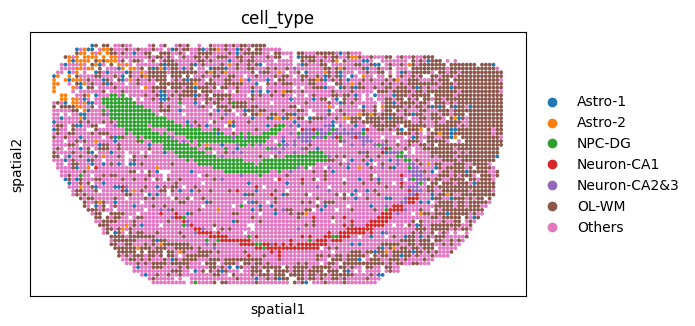

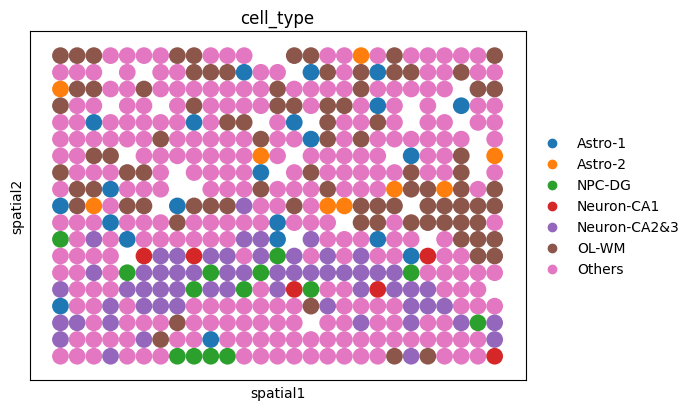

In [7]:
# 1. setting OL-WM region
adata_O = adata[adata.obs["slice"] == "Hippocampus_O_2_1", :]
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1", :]
# ol_cells = adata_O[adata_O.obs["cell_type"] == "NPC-DG"]
ol_cells = adata_O.copy()
x = ol_cells.obsm["spatial"][:, 0]
y = ol_cells.obsm["spatial"][:, 1]
print(x.min(), x.max(), y.min(), y.max())

ol_roi = ol_cells[
    (ol_cells.obsm["spatial"][:, 0] > 60) &    
    (ol_cells.obsm["spatial"][:, 1] > 10) &    
    (ol_cells.obsm["spatial"][:, 0] < 88) &      
    (ol_cells.obsm["spatial"][:, 1] < 30)
].copy()
print(ol_roi)
sc.pl.spatial(ol_cells, color="cell_type", spot_size=1)

ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"],
    categories=ol_cells.obs["cell_type"].cat.categories, 
    ordered=True
)


ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]

fig = sc.pl.spatial(
    ol_roi,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True 
)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

# fig.savefig(f"{out_fig_dir}/ma_spatial_roi.pdf", bbox_inches="tight")

x: 1.0 ~ 85.0, y: 1.0 ~ 52.0
ROI cells: 495


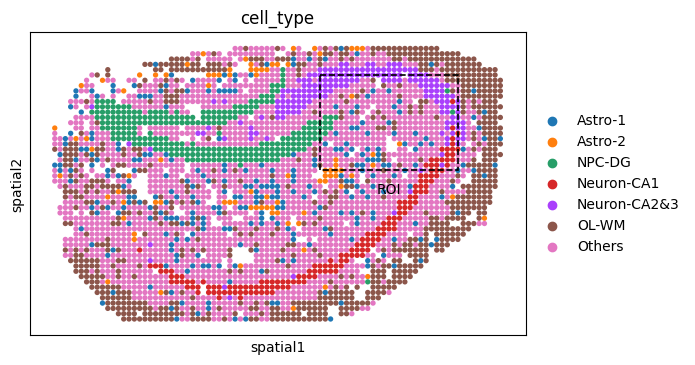

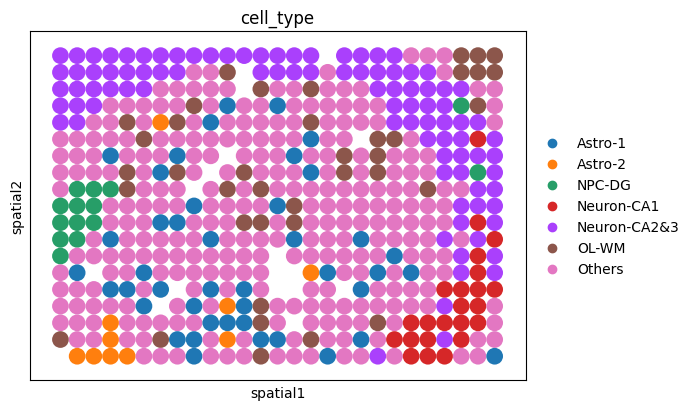

In [8]:
# === Matplotlib settings (ensure editable text in PDF/SVG) ===
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# === Ensure output directory ===
os.makedirs(out_fig_dir, exist_ok=True)

# === Step 1: subset slice ===
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1"].copy()

# === Step 2: coordinates ===
x = adata_Y.obsm["spatial"][:, 0]
y = adata_Y.obsm["spatial"][:, 1]
print(f"x: {x.min():.1f} ~ {x.max():.1f}, y: {y.min():.1f} ~ {y.max():.1f}")

# === Step 3: ROI bounds (x in (60, 88), y in (10, 30)) ===
roi_mask = (x > 50) & (x < 78) & (y > 5) & (y < 25)
y_roi = adata_Y[roi_mask].copy()
print(f"ROI cells: {y_roi.n_obs}")

# === Step 4: sync categories & colors ===
adata_Y.obs["cell_type"] = adata_Y.obs["cell_type"].astype("category")
cats = adata_Y.obs["cell_type"].cat.categories
y_roi.obs["cell_type"] = pd.Categorical(y_roi.obs["cell_type"], categories=cats, ordered=True)

adata_Y.uns["cell_type_colors"] = adata_Y.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(cats)]
)
y_roi.uns["cell_type_colors"] = adata_Y.uns["cell_type_colors"]

# === Step 5a: full view with ROI box ===
fig1 = sc.pl.spatial(adata_Y, color="cell_type", spot_size=1, show=False, return_fig=True)

# Add dashed ROI box
roi_xy = y_roi.obsm["spatial"]
xmin, xmax = roi_xy[:, 0].min(), roi_xy[:, 0].max()
ymin, ymax = roi_xy[:, 1].min(), roi_xy[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2

ax = fig1.axes[0]
rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                 linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(xcenter, ymax + 5, "ROI", color='black', fontsize=10, ha='center', va='bottom')

# === Step 5b: ROI-only ===
fig2 = sc.pl.spatial(y_roi, color="cell_type", spot_size=1, show=False, return_fig=True)


In [ ]:
ol_roi.obs["brain_region"] = ol_roi.obs["slice"]
ol_roi.obs["brain_region_main"] = ol_roi.obs["slice"]
ol_roi.obsm["spatial"] = ol_roi.obsm["spatial"].astype(np.float32)
ol_roi = compute_deviation_bin_rapid_v2(ol_roi)
ol_roi = convert_spatial_to_um(ol_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
ol_roi, _ = compute_density_token(ol_roi, radius)

y_roi.obs["brain_region"] = y_roi.obs["slice"]
y_roi.obs["brain_region_main"] = y_roi.obs["slice"]
y_roi.obsm["spatial"] = y_roi.obsm["spatial"].astype(np.float32)
y_roi = compute_deviation_bin_rapid_v2(y_roi)
y_roi = convert_spatial_to_um(y_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
y_roi, _ = compute_density_token(y_roi, radius)

In [10]:
adata_fov_OL = ad.concat([ol_roi, y_roi], join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
output_prefix_ori = "original"
adata_fov_OL.obs["split"] = "train"
os.makedirs(output_dir, exist_ok=True)
ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
adata_fov_OL.write(ori_input_adata_path)
print(f"Saved selected slices to: {ori_input_adata_path}")

... storing 'slice_brain_area' as categorical
... storing 'split' as categorical


Saved selected slices to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad


In [11]:
# ========== 6. Run Original Inference ==========
adata_ori = run_bbcellformer_pipeline(
    adata_path=ori_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_ori,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    weight_mode="expression",
    use_batch=False,
    use_spatial=True,
    force_tokenize=True,
    do_fit=True,  # recommended to set to True for original reconstruction
    device=device,
    fit_epochs=100,
)
print("Original reconstruction complete. Embeddings and model saved.")
print("adata_ori:", adata_ori)

ori_result_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")


Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad
before quality control adata shape: (976, 20318)


After HVG (5000) selection: (976, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:04<00:00,  4.31s/it]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.12 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:12<00:00,  1.25it/s]


...

Epoch 98 | Train loss: 6799.0413 | Valid loss: 6839.3455


100%|██████████| 100/100 [00:57<00:00,  1.75it/s]

Epoch 99 | Train loss: 6827.6941 | Valid loss: 6835.8557
After filtering, 20316 genes remain.



... storing 'split' as categorical
... storing 'platform' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_embeddings.npz
Original reconstruction complete. Embeddings and model saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_reg

In [12]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
from scipy.stats import wasserstein_distance

def analyze_embedding_similarity_change_OE(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb", gamma=1.0
):
    """
    Compute cosine similarity, Euclidean distance, Wasserstein distance (EMD) and MMD 
    between perturbed and original young cell embeddings, with old cells as reference.
    """
    # ---- Extract embeddings ----
    emb_young_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_young_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_young) &
        (adata_perturb_result.obs["cell_type"] == target_celltype)
    ]
    emb_old = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]

    # ---- Mean embedding of old cells (作为对照参考) ----
    mean_old_emb = emb_old.mean(axis=0)

    # ---- Cosine similarity ----
    sim_ori = cosine_similarity(emb_young_ori, mean_old_emb.reshape(1, -1))
    sim_perturb = cosine_similarity(emb_young_perturb, mean_old_emb.reshape(1, -1))

    # ---- Euclidean distance ----
    dist_ori = euclidean_distances(emb_young_ori, mean_old_emb.reshape(1, -1))
    dist_perturb = euclidean_distances(emb_young_perturb, mean_old_emb.reshape(1, -1))

    # ---- Wasserstein (1D per dimension, averaged) ----
    emd_ori = np.mean([wasserstein_distance(emb_young_ori[:, i], emb_old[:, i]) 
                       for i in range(emb_old.shape[1])])
    emd_perturb = np.mean([wasserstein_distance(emb_young_perturb[:, i], emb_old[:, i]) 
                           for i in range(emb_old.shape[1])])

    # ---- MMD (with RBF kernel) ----
    def compute_mmd(X, Y, gamma):
        Kxx = rbf_kernel(X, X, gamma=gamma).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma).mean()
        return Kxx + Kyy - 2 * Kxy

    mmd_ori = compute_mmd(emb_young_ori, emb_old, gamma)
    mmd_perturb = compute_mmd(emb_young_perturb, emb_old, gamma)

    return {
        "cosine": (sim_ori.mean(), sim_perturb.mean()),
        "euclidean": (dist_ori.mean(), dist_perturb.mean()),
        "emd": (emd_ori, emd_perturb),
        "mmd": (mmd_ori, mmd_perturb),
    }

In [13]:
def analyze_embedding_similarity_change_similarity_niche_OE(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb", gamma=1.0
):
    """
    Compare niche embeddings before/after perturbation, when perturbation is applied to the young slice.
    Excludes target cell type. Uses old niche as reference.
    Returns cosine similarity, Euclidean distance, EMD (Wasserstein), and MMD.
    """
    # --- slice masks (exclude target_celltype) ---
    mask_young_ori = (
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    )
    mask_young_pert = (
        (adata_perturb_result.obs["slice"] == target_slice_young) &
        (adata_perturb_result.obs["cell_type"] != target_celltype)
    )
    mask_old = (
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    )

    # --- extract embeddings ---
    emb_young_ori = np.asarray(adata_ori_result.obsm[embedding_key][mask_young_ori])
    emb_young_perturb = np.asarray(adata_perturb_result.obsm[embedding_key][mask_young_pert])
    emb_old = np.asarray(adata_ori_result.obsm[embedding_key][mask_old])

    # --- basic checks ---
    if emb_young_ori.size == 0:
        raise ValueError("No young cells found before perturbation.")
    if emb_young_perturb.size == 0:
        raise ValueError("No young cells found after perturbation.")
    if emb_old.size == 0:
        raise ValueError("No old cells found for reference.")

    # --- handle NaNs robustly ---
    emb_young_ori = np.nan_to_num(emb_young_ori, nan=0.0)
    emb_young_perturb = np.nan_to_num(emb_young_perturb, nan=0.0)
    emb_old = np.nan_to_num(emb_old, nan=0.0)

    # --- mean vector of old niche ---
    mean_old_emb = emb_old.mean(axis=0, keepdims=True)

    # --- cosine similarity (higher = closer to old) ---
    sim_ori = cosine_similarity(emb_young_ori, mean_old_emb).mean()
    sim_perturb = cosine_similarity(emb_young_perturb, mean_old_emb).mean()

    # --- Euclidean distance (lower = closer to old) ---
    dist_ori = euclidean_distances(emb_young_ori, mean_old_emb).mean()
    dist_perturb = euclidean_distances(emb_young_perturb, mean_old_emb).mean()

    # --- EMD / Wasserstein (1D per dimension, averaged) ---
    d = emb_old.shape[1]
    emd_ori = np.mean([wasserstein_distance(emb_young_ori[:, i], emb_old[:, i]) for i in range(d)])
    emd_perturb = np.mean([wasserstein_distance(emb_young_perturb[:, i], emb_old[:, i]) for i in range(d)])

    # --- MMD with RBF kernel ---
    def compute_mmd(X, Y, gamma_):
        Kxx = rbf_kernel(X, X, gamma=gamma_).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma_).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma_).mean()
        return Kxx + Kyy - 2 * Kxy

    mmd_ori = compute_mmd(emb_young_ori, emb_old, gamma)
    mmd_perturb = compute_mmd(emb_young_perturb, emb_old, gamma)

    return {
        "cosine": (float(sim_ori), float(sim_perturb)),
        "euclidean": (float(dist_ori), float(dist_perturb)),
        "emd": (float(emd_ori), float(emd_perturb)),
        "mmd": (float(mmd_ori), float(mmd_perturb)),
    }

In [32]:
# ========== 7. Perturbation: Knock out Igkc in old LL-WM cells ==========
perturbed_adata_final, perturbed_cells_final = apply_gene_perturbation(
    adata=adata_fov_OL,
    gene_list = ["Igkc"],
    mode="overexpress", # OE
    filter_by={"slice": "Hippocampus_Y_2_1", "cell_type": "OL-WM"},
    value=60,
)   
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s) to 60.")

# Save perturbed input data
output_prefix_perturb = "ko_old_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_final = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_final)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_final.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== 9. Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"


Perturbed 39 cells: set expression of target gene(s) to 60.
Perturbed input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  1.83it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.05 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:12<00:00,  1.31it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
Time cost:  0.30145270427068077
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filter

... storing 'split' as categorical
... storing 'platform' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'ba

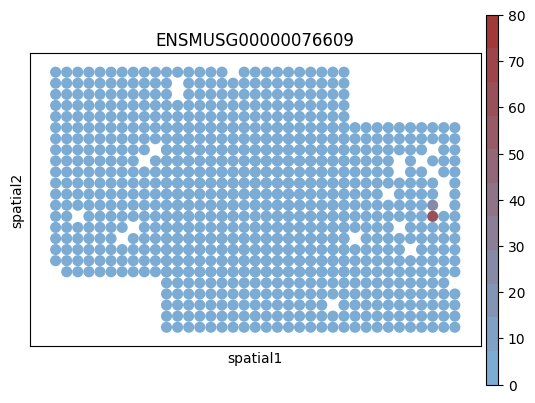

In [15]:
custom_colors = ["#7CACD4", "#A13939"]  # 蓝 → 红
cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", custom_colors, N=10+1)
sc.pl.spatial(
    adata_fov_OL,
    color="ENSMUSG00000076609",
    spot_size=1,
    cmap=cmap,
    vmax=80,
    show=False, 
)

# ensure editable text in vector formats
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

fig = plt.gcf()         # get current figure
# fig.savefig(f"{out_fig_dir}/ma_Igkc_oldandyoung.pdf",
#             bbox_inches="tight")
# plt.close(fig)

Text(0.5, 0.98, 'Spatial Response to Igkc Overexpression in OL-WM Cells')

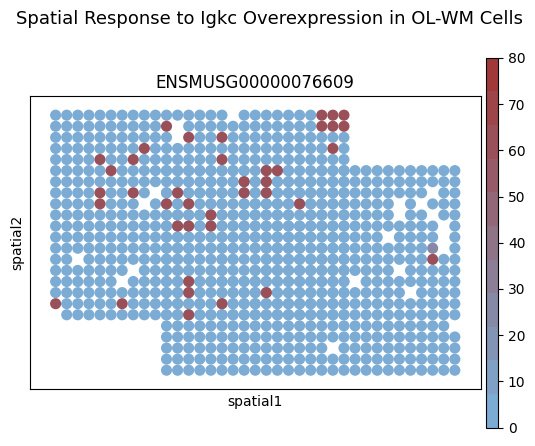

In [16]:

# draw but do not show
custom_colors = ["#7CACD4", "#A13939"]  # 蓝 → 红
cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", custom_colors, N=10+1)
sc.pl.spatial(
    perturbed_adata_final,
    color="ENSMUSG00000076609",
    spot_size=1,
    cmap=cmap,
    vmax=80,
    show=False,          # <- keep figure in memory
)

# ensure editable text in vector formats
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"

fig = plt.gcf()         # get current figure
fig.suptitle("Spatial Response to Igkc Overexpression in OL-WM Cells", fontsize=13, y=0.98)

In [33]:
result = analyze_embedding_similarity_change_OE(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb")

sim_ori_final, sim_perturb_final = result["cosine"]
dist_ori_final, dist_perturb_final = result["euclidean"]
emd_ori_final, emd_perturb_final = result["emd"]
mmd_ori_final, mmd_perturb_final = result["mmd"]
print("Cosine similarity: before KO = {:.4f}, after KO = {:.4f}".format(sim_ori_final, sim_perturb_final))
print("Euclidean distance: before KO = {:.4f}, after KO = {:.4f}".format(dist_ori_final, dist_perturb_final))
print("Wasserstein distance (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_ori_final, emd_perturb_final))
print("MMD: before KO = {:.4f}, after KO = {:.4f}".format(mmd_ori_final, mmd_perturb_final))

result_niche = analyze_embedding_similarity_change_similarity_niche_OE(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
sim_ori_final_niche, sim_perturb_final_niche = result_niche["cosine"]
dist_ori_final_niche, dist_perturb_final_niche = result_niche["euclidean"]
emd_ori_final_niche, emd_perturb_final_niche = result_niche["emd"]
mmd_ori_final_niche, mmd_perturb_final_niche = result_niche["mmd"]
print("Cosine similarity_niche: before KO = {:.4f}, after KO = {:.4f}".format(sim_ori_final_niche, sim_perturb_final_niche))
print("Euclidean distance_niche: before KO = {:.4f}, after KO = {:.4f}".format(dist_ori_final_niche, dist_perturb_final_niche))
print("Wasserstein distance_niche (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_ori_final_niche, emd_perturb_final_niche))
print("MMD_niche: before KO = {:.4f}, after KO = {:.4f}".format(mmd_ori_final_niche, mmd_perturb_final_niche))

Cosine similarity: before KO = 0.0835, after KO = 0.1260
Euclidean distance: before KO = 12.7663, after KO = 12.3604
Wasserstein distance (EMD): before KO = 0.3652, after KO = 0.3606
MMD: before KO = 0.0370, after KO = 0.0370
Cosine similarity_niche: before KO = 0.0510, after KO = 0.0551
Euclidean distance_niche: before KO = 13.6393, after KO = 13.6403
Wasserstein distance_niche (EMD): before KO = 0.3883, after KO = 0.3880
MMD_niche: before KO = 0.0051, after KO = 0.0051


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

def plot_cosine_to_centroids_with_perturb(
    adata_ori,
    adata_perturb,
    slice_young,
    slice_old,
    target_celltype=None,
    celltype_key="cell_type",
    emb_key="X_emb",
    title="Cell state positioning relative to young and old centroids",
    agg_by_celltype=False,
    exclude_celltype=False,
    save_path=None
):
    # ====== get embedding ======
    X_ori = adata_ori.obsm[emb_key]
    if hasattr(X_ori, "toarray"):
        X_ori = X_ori.toarray()
    X_perturb = adata_perturb.obsm[emb_key]
    if hasattr(X_perturb, "toarray"):
        X_perturb = X_perturb.toarray()

    if exclude_celltype and target_celltype is not None:
        mask_young_ori = (
            (adata_ori.obs["slice"].astype(str) == slice_young) &
            (adata_ori.obs[celltype_key] == target_celltype)
        )
        mask_young_pert = (
            (adata_perturb.obs["slice"].astype(str) == slice_young) &
            (adata_perturb.obs[celltype_key] == target_celltype)
        )
        mask_old = (
            (adata_ori.obs["slice"].astype(str) == slice_old) &
            (adata_ori.obs[celltype_key] == target_celltype)
        )
    else:
        sl_ori = adata_ori.obs["slice"].astype(str).values
        sl_perturb = adata_perturb.obs["slice"].astype(str).values
        mask_young_ori = sl_ori == slice_young
        mask_young_pert = sl_perturb == slice_young
        mask_old = sl_ori == slice_old

    X_unit_ori = normalize(X_ori, norm="l2", axis=1)
    young_centroid = normalize(X_unit_ori[mask_young_ori].mean(axis=0, keepdims=True), norm="l2", axis=1)[0]
    old_centroid   = normalize(X_unit_ori[mask_old].mean(axis=0, keepdims=True),   norm="l2", axis=1)[0]

    def cos_coords(X):
        X_unit = normalize(X, norm="l2", axis=1)
        cos_y = X_unit @ young_centroid
        cos_o = X_unit @ old_centroid
        return cos_y, cos_o

    cos_y_y, cos_o_y = cos_coords(X_ori[mask_young_ori])
    cos_y_o, cos_o_o = cos_coords(X_ori[mask_old])
    cos_y_p, cos_o_p = cos_coords(X_perturb[mask_young_pert])

    plt.figure(figsize=(6.5, 6))

    if not agg_by_celltype:
        plt.scatter(cos_y_y, cos_o_y, s=40, c="#076a3aff", alpha=0.9, edgecolor="none", label="Young cells")
        plt.scatter(cos_y_o, cos_o_o, s=40, c="#073f6aff", alpha=0.9, edgecolor="none",label="Old cells")
        plt.scatter(cos_y_p, cos_o_p, s=40, c="#791f1fff", alpha=0.9, edgecolor="none",label="Perturbed Young cells")
        plt.scatter(np.mean(cos_y_y), np.mean(cos_o_y), c="#076a3aff", s=200, marker="*", edgecolor="white", linewidth=1, label="Young mean")
        plt.scatter(np.mean(cos_y_o), np.mean(cos_o_o), c="#073f6aff", s=200, marker="*", edgecolor="white", linewidth=1, label="Old mean")
        plt.scatter(np.mean(cos_y_p), np.mean(cos_o_p), c="#791f1fff", s=200, marker="*", edgecolor="white", linewidth=1, label="Perturbed Young mean")

    else:
        for cos_y, cos_o, label, mask, adata in [
            (cos_y_y, cos_o_y, "Young", mask_young_ori, adata_ori),
            (cos_y_o, cos_o_o, "Old", mask_old, adata_ori),
            (cos_y_p, cos_o_p, "Perturbed Young", mask_young_pert, adata_perturb)
        ]:
            ct = adata.obs[celltype_key].values[mask]
            df = pd.DataFrame({"celltype": ct, "cos_y": cos_y, "cos_o": cos_o})
            df_mean = df.groupby("celltype")[["cos_y", "cos_o"]].mean().reset_index()
            plt.scatter(df_mean["cos_y"], df_mean["cos_o"], s=50, alpha=0.9, label=label)

    lim_min = min(cos_y_y.min(), cos_o_y.min(), cos_y_o.min(), cos_o_o.min(), cos_y_p.min(), cos_o_p.min())
    lim_max = max(cos_y_y.max(), cos_o_y.max(), cos_y_o.max(), cos_o_o.max(), cos_y_p.max(), cos_o_p.max())
    pad = 0.02
    plt.plot([lim_min-pad, lim_max+pad], [lim_min-pad, lim_max+pad], ls="--", c="gray", lw=1)
    plt.xlim(lim_min-pad, lim_max+pad)
    plt.ylim(lim_min-pad, lim_max+pad)

    plt.xlabel("Cosine similarity to young centroid")
    plt.ylabel("Cosine similarity to old centroid")
    plt.title(title)
    plt.legend()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(alpha=0.2, ls="--")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()

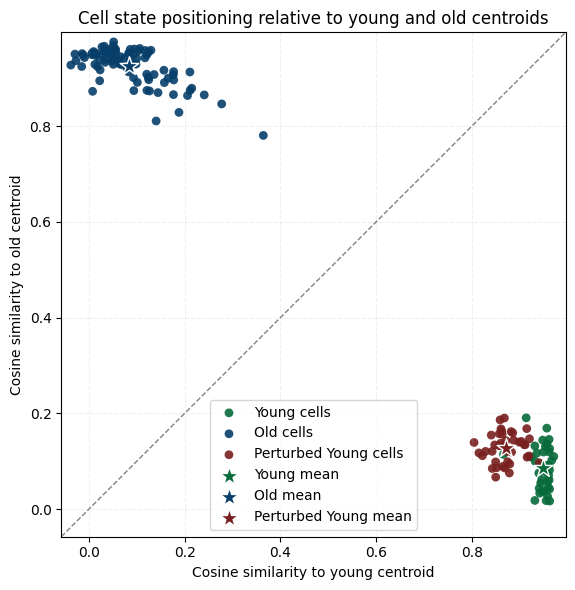

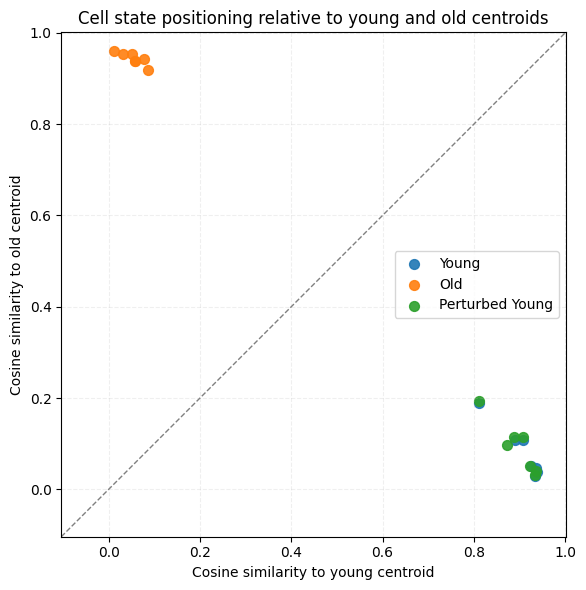

In [22]:
plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=True,
    # save_path=os.path.join(f"{out_fig_dir}/target_cell_cell_stat_Igkc.pdf")
)

# # 只分析 niche-only
plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=False,
    agg_by_celltype=True,
    # save_path=os.path.join(f"{out_fig_dir}/niche_cell_cell_stat.pdf")
)

In [28]:
# ========== 7. Perturbation: Knock out Igkc in young cells ==========
perturbed_adata_final, perturbed_cells_final = apply_gene_perturbation(
    adata=adata_fov_OL,
    gene_list = ["Igkc"],
    mode="overexpress", # OE
    filter_by={"slice": "Hippocampus_Y_2_1"},
    value=60,
)   
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s) to 60.")
# Save perturbed input data
output_prefix_perturb = "ko_old_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_allcelltype = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_allcelltype)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_allcelltype.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== 9. Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"


Perturbed 495 cells: set expression of target gene(s) to 60.
Perturbed input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.06 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:12<00:00,  1.28it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
Time cost:  0.29590961535771687
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filter

... storing 'split' as categorical
... storing 'platform' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inneroe/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'ba

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_global_euclidean_shift(
    adata_ori,
    adata_perturb,
    emb_key="X_emb",
    title="Perturbation-Induced Changes in Euclidean Distance to Global Reference",
    cmap="RdBu_r",
    save_path=None
):
    # ====== get embedding ======
    X_ori = adata_ori.obsm[emb_key]
    if hasattr(X_ori, "toarray"):
        X_ori = X_ori.toarray()

    X_perturb = adata_perturb.obsm[emb_key]
    if hasattr(X_perturb, "toarray"):
        X_perturb = X_perturb.toarray()

    global_centroid = X_ori.mean(axis=0, keepdims=True)

    # ====== cal euc ======
    dist_before = np.linalg.norm(X_ori - global_centroid, axis=1)
    dist_after = np.linalg.norm(X_perturb - global_centroid, axis=1)

    # ====== KDE  Plot ======
    plt.figure(figsize=(7, 6))
    sns.kdeplot(
        x=dist_before,
        y=dist_after,
        fill=True,
        cmap=cmap,
        bw_adjust=0.8,
        thresh=0.02,
        levels=60
    )

    min_val = min(dist_before.min(), dist_after.min())
    max_val = max(dist_before.max(), dist_after.max())
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray', lw=1.2)
    plt.xlabel("Euclidean Distance to Global Centroid (Before Perturbation)", fontsize=12)
    plt.ylabel("Euclidean Distance to Global Centroid (After Perturbation)", fontsize=12)
    plt.title(title, fontsize=13, pad=10)
    plt.grid(alpha=0.2, lw=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=500)
        plt.close()
    else:
        plt.show()

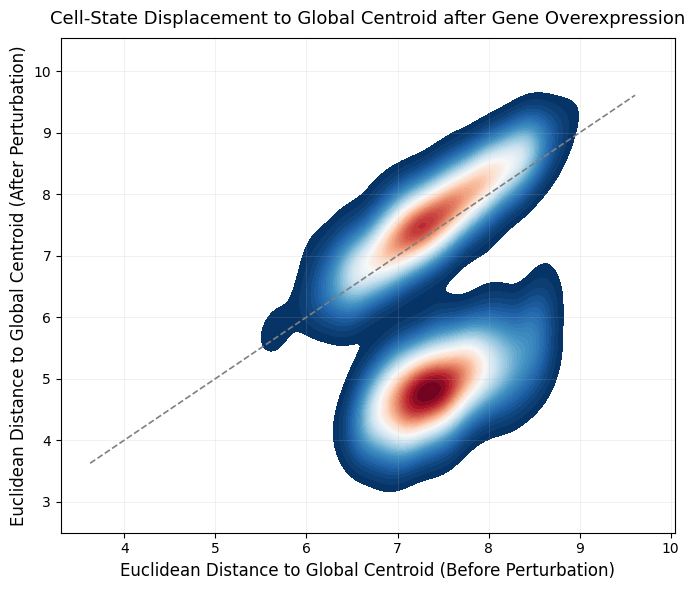

In [29]:

plot_global_euclidean_shift(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_allcelltype,
    title="Cell-State Displacement to Global Centroid after Gene Overexpression",
    # save_path="figures/Fig4d_Global_Euclidean_Shift.pdf"
)